# Train the latent draft model on extracted traces

Data comes from `fastdocling-extract` (`data/traces/*.safetensors`): per page, the target model's
hidden states at every position plus the tokens it generated. `fastdocling.data` streams these
from disk one page at a time and cuts the DocTags region into fixed-length windows, so the whole
corpus (tens of GB) never has to fit in memory.

**Alignment.** Hidden state `i` is the target's state after reading token `i`; the target's LM head
turned it into token `i+1`. In speculative decoding that token is already known when the draft
runs (it is the "bonus" token of the verification step), so the draft heads predict the tokens
*after* it: head `j` predicts offset `j+1` from the state it reads. Training targets follow the
same convention (`fastdocling.data.FIRST_OFFSET = 2`), so the teacher-forced acceptance metric
and the live speculative loop measure the same thing.

**Inputs.** `FEATURES="last"` feeds the final normed state (576-d). `FEATURES="eagle3"` feeds the
concatenation of layers 2/14/27 (1728-d), the EAGLE-3 recipe; the draft then learns an input
projection back to 576.

**Caching across kernel restarts.** Decoding is greedy everywhere, so most expensive results are
deterministic and are stored under `data/cache/`: a trained run is keyed by its full configuration
(hyper-parameters, training page set, model/loss source) and reloaded instead of retrained; every
end-to-end page decode (baseline and speculative) is keyed by target, draft weights, settings and
page image. `FORCE_TRAIN` / `REFRESH_DECODES` in the config cell bypass them. The target's LM head
is read straight from its safetensors, so training never loads the 258M model at all.

In [13]:
import hashlib
import json
import marshal
from collections import Counter
from datetime import datetime
from pathlib import Path
from time import perf_counter

import numpy as np
import torch
from cut_cross_entropy import linear_cross_entropy
from torch import nn
from torch.nn import functional as F
from torchinfo import summary
from tqdm.auto import tqdm

from fastdocling.data import FIRST_OFFSET, HIDDEN_SIZE, corpus_key, input_dim, iterate_batches, key_of, plan, scan_traces, split
from fastdocling.medusa import MedusaDraft, export_medusa_checkpoint
from fastdocling.target import MODEL_ID, load_lm_head

VOCAB_SIZE = 100_352
# Paths resolve against the repo root, not the working directory: this notebook lives in
# notebooks/medusa/, so a bare Path("data/traces") would point at notebooks/medusa/data/traces.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
TRACES = ROOT / "data/traces"
CACHE = ROOT / "data/cache"     # results reused across kernel restarts: trained runs, end-to-end decodes

# --- training configuration -------------------------------------------------------------
CONTEXT_LENGTH = 64   # window the draft attends over
HORIZON = 4           # future tokens predicted per position (NUM_PREDICTIONS)
BATCH_SIZE = 64
EPOCHS = 1             # see the epoch table below
FEATURES = "last"      # or "eagle3"
# Which draft to build.  "latent" is the windowed causal block -- best acceptance, but it
# cannot be handed to vLLM (no proposer interface takes a window of hidden states).
# "medusa" is parallel residual heads over the *current* state only: weaker, but it is the
# one shape vLLM will host in-engine.  Both emit [B, T, HORIZON, 576], so every cell below
# -- loss, acceptance, decode -- works unchanged either way.
DRAFT_ARCH = "medusa"  # or "latent"
MEDUSA_LAYERS = 1      # residual SiLU projections per head (medusa only)
MUON_LR = 0.02         # Muon: 2-D weight matrices inside the block and heads
ADAMW_LR = 3e-4        # AdamW: embeddings, norms, biases
WARMUP_STEPS = 10
EVAL_EVERY = 100        # steps between acceptance-rate evaluations on the holdout set
EVAL_BATCHES = 8       # holdout batches used for the running acceptance metric
OUTPUT = ROOT / f"checkpoints/{DRAFT_ARCH}_draft.pt"

# --- decode backend (the throughput cells only; training never loads the target) ---------
DECODE_BACKEND = "auto"   # "auto" | "mlx" | "transformers" | "vllm"  -- see fastdocling.decode
TARGET_DECODE_TPS = 188.0  # single-stream target decode rate used by the teacher-forced estimate
                           # below.  Machine- and backend-specific: the decode cells print the
                           # measured value for this machine, so copy it here after running them.

# --- caching ----------------------------------------------------------------------------
FORCE_TRAIN = False       # True: retrain even if this exact configuration was trained before
REFRESH_DECODES = False   # True: re-run (and re-time) end-to-end page decodes instead of reading stored ones

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")

In [14]:
infos = scan_traces(TRACES, min_completion=CONTEXT_LENGTH + HORIZON + FIRST_OFFSET - 1)  # one full training window
train_infos, holdout_infos = split(infos, holdout_fraction=0.02)
schedule = plan(train_infos, CONTEXT_LENGTH, BATCH_SIZE, HORIZON)
TOTAL_STEPS = schedule.steps_for_epochs(EPOCHS)
print(schedule.describe(steps=TOTAL_STEPS))
CORPUS_KEY = corpus_key(train_infos)   # fingerprint of the training page set; keys the vocab and run caches
print(f"holdout: {len(holdout_infos)} pages; corpus key {CORPUS_KEY}")

4,959 pages, 5,648,741 usable DocTags positions
context=64 horizon=4 batch=64 -> 4,096 tokens/step
79,458 windows/epoch -> 1,241 steps/epoch
1,241 steps = 1.00 epochs
holdout: 101 pages; corpus key c5aa384623


## How many epochs?

An **epoch** is one pass over every non-overlapping window the corpus yields:

```
tokens_per_step   = CONTEXT_LENGTH * BATCH_SIZE
windows_per_epoch = sum over pages of  floor(completion_tokens / (CONTEXT_LENGTH + HORIZON + 1))
steps_per_epoch   = windows_per_epoch // BATCH_SIZE
epochs            = steps / steps_per_epoch
```

Pages average ~1,000 generated DocTags tokens, so long contexts waste data: a page shorter than
`CONTEXT_LENGTH + HORIZON` yields no window at all, and the remainder of every page is dropped.
Measured on an earlier, larger corpus (958 training pages, ~980k usable positions, 4.6M-parameter draft); the current run uses context 128, batch 8 on the pages listed above, so re-read the printed plan rather than this table:

| context | batch | tokens/step | windows/epoch | steps/epoch | data kept |
|--------:|------:|------------:|--------------:|------------:|----------:|
| 256     | 16    | 4,096       | 3,298         | 206         | 87%       |
| 512     | 8     | 4,096       | 1,430         | 178         | 75%       |
| 1024    | 4     | 4,096       | 483           | 120         | 51%       |

The full corpus (5,379 pages) is ~5.5M positions: about **1,150 steps/epoch** at context 256,
batch 16. Successive epochs cut windows at different random offsets, so repeated passes are not
exact duplicates.

**Recommendation.** For a draft of a few million parameters, 2-4 epochs on 5.5M tokens is the right range:
one epoch underfits (the draft needs to see each DocTags pattern several times), and beyond four
the holdout token accuracy stops improving while training loss keeps falling. Start with
`EPOCHS = 3` (~3,500 steps at 4,096 tokens/step, ~14M tokens seen) and watch the holdout
accuracy printed after each epoch. Keep `CONTEXT_LENGTH` at 256 or 512 unless windows are packed
across pages.

In [ ]:
class Attention(nn.Module):
    """Multi-head causal self-attention with a fused QKV projection.

    Takes an already-normalised input: the pre-norm lives on the block, so this is just the
    attention itself.
    """

    def __init__(self, dim: int, heads: int) -> None:
        super().__init__()
        if dim % heads:
            raise ValueError(f"dim {dim} is not divisible by heads {heads}")
        self.heads = heads
        # One projection for Q, K and V: a single [dim, 3*dim] matmul instead of three, stacked
        # along the output axis exactly as nn.MultiheadAttention's in_proj_weight.
        self.in_proj = nn.Linear(dim, 3 * dim)
        self.out_proj = nn.Linear(dim, dim)
        # Match nn.MultiheadAttention's init: Xavier on the fused QKV, zero on both biases.
        nn.init.xavier_uniform_(self.in_proj.weight)
        nn.init.zeros_(self.in_proj.bias)
        nn.init.zeros_(self.out_proj.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        # [B, T, 3D] -> q, k, v each [B, heads, T, head_dim].  Viewing the last axis as
        # (3, heads, head_dim) is the same ordering as three contiguous [B, T, D] chunks.
        qkv = self.in_proj(x).view(B, T, 3, self.heads, D // self.heads)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)
        # is_causal applies the mask implicitly.  Passing an explicit mask instead materialises a
        # [T, T] bool tensor on every single call -- pure overhead on the draft's critical path.
        attn = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.out_proj(attn.transpose(1, 2).reshape(B, T, D))


class MLP(nn.Module):
    """Position-wise feed-forward: dim -> ff -> dim, exact-erf GELU in between."""

    def __init__(self, dim: int, ff: int) -> None:
        super().__init__()
        self.linear1 = nn.Linear(dim, ff)
        self.linear2 = nn.Linear(ff, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(F.gelu(self.linear1(x)))


class TransformerBlock(nn.Module):
    """Pre-norm causal block: ``x + attn(norm1(x))``, then ``x + mlp(norm2(x))``.

    Written out rather than assembled from ``nn.TransformerEncoderLayer`` so nothing sits on the
    draft's critical path that a draft call does not need, and so the torch and MLX drafts read
    as the same model in two frameworks (see ``fastdocling.draft_mlx``).
    """

    def __init__(self, dim: int, heads: int, ff: int) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, ff)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))


class LatentDraft(nn.Module):
    """One causal Transformer block with parallel future-token heads.

    Reads a window of the target's hidden states and predicts, for every position, the states of
    the next ``horizon`` tokens at once -- head ``j`` predicts offset ``FIRST_OFFSET + j``.  The
    target's own frozen LM head turns those into token logits, so the draft never learns a
    vhave ocabulary projection of its own.
    """

    def __init__(self, context_length: int, in_dim: int = HIDDEN_SIZE, horizon: int = 4,
                 heads: int = 9, ff: int = HIDDEN_SIZE * 2) -> None:
        super().__init__()
        self.horizon = horizon
        # "last" features are already 576-wide; EAGLE-3 taps (1728) need projecting down.
        self.proj = None if in_dim == HIDDEN_SIZE else nn.Linear(in_dim, HIDDEN_SIZE)
        self.positions = nn.Embedding(context_length, HIDDEN_SIZE)
        self.block = TransformerBlock(HIDDEN_SIZE, heads, ff)
        self.norm = nn.LayerNorm(HIDDEN_SIZE)
        self.future_heads = nn.Linear(HIDDEN_SIZE, horizon * HIDDEN_SIZE)

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        """[B, T, in_dim] -> [B, T, horizon, 576]"""
        T = hidden_states.shape[1]
        x = hidden_states if self.proj is None else self.proj(hidden_states)
        # Slicing the embedding table beats positions(arange(T)): no index tensor, no gather.
        x = x + self.positions.weight[:T]
        x = self.norm(self.block(x))
        return self.future_heads(x).unflatten(-1, (self.horizon, HIDDEN_SIZE))


# Reuse Granite's frozen vocabulary projection, so 576-wide outputs become token logits.
# Read straight from the cached safetensors (~0.1 s); the full target is only loaded by the decode cells.
lm_head = load_lm_head(MODEL_ID).to(device)
assert lm_head.shape == (VOCAB_SIZE, HIDDEN_SIZE), lm_head.shape

draft = (MedusaDraft(HORIZON, input_dim(FEATURES), num_layers=MEDUSA_LAYERS)
         if DRAFT_ARCH == "medusa" else
         LatentDraft(CONTEXT_LENGTH, input_dim(FEATURES))).to(device)
# Muon orthogonalizes the momentum of each 2-D weight matrix (Newton-Schulz), which suits the
# transformer block and heads; embeddings, LayerNorm gains and biases stay on AdamW.
muon_params = [p for n, p in draft.named_parameters() if p.ndim == 2 and not n.startswith("positions")]
adamw_params = [p for n, p in draft.named_parameters() if not (p.ndim == 2 and not n.startswith("positions"))]
optimizers = [
    torch.optim.Muon(muon_params, lr=MUON_LR, weight_decay=0.01, momentum=0.95, nesterov=True),
    torch.optim.AdamW(adamw_params, lr=ADAMW_LR, weight_decay=0.01),
]
warmup_cosine = lambda s: min(1.0, (s + 1) / WARMUP_STEPS) * 0.5 * (1 + np.cos(np.pi * min(1.0, s / max(1, TOTAL_STEPS))))
lr_schedules = [torch.optim.lr_scheduler.LambdaLR(o, warmup_cosine) for o in optimizers]
print(f"{sum(p.numel() for p in draft.parameters()):,} draft parameters, input dim {input_dim(FEATURES)}")
print(f"Muon on {sum(p.numel() for p in muon_params):,} params, AdamW on {sum(p.numel() for p in adamw_params):,}")
summary(draft, input_size=(BATCH_SIZE, CONTEXT_LENGTH, input_dim(FEATURES)), depth=3,
        col_names=("input_size", "output_size", "num_params", "mult_adds"),
        row_settings=("var_names",))

4,027,968 draft parameters, input dim 576
Muon on 3,981,312 params, AdamW on 46,656


In [12]:
def loss_fn(predicted: torch.Tensor, target_hidden: torch.Tensor, target_tokens: torch.Tensor):
    # Apple CCE avoids materializing the 100k-token logit matrix per head.
    token_loss = sum(
        linear_cross_entropy(predicted[:, :, k].flatten(0, 1), lm_head, target_tokens[:, :, k].flatten(), impl="torch_compile")
        for k in range(HORIZON)
    ) / HORIZON
    hidden_loss = F.mse_loss(predicted, target_hidden)
    return token_loss + 0.1 * hidden_loss, token_loss


# Fixed holdout batches, loaded once, for the running acceptance metric.
eval_batches = []
for batch in iterate_batches(holdout_infos, CONTEXT_LENGTH, BATCH_SIZE, HORIZON, FEATURES, seed=0, device=device):
    eval_batches.append(batch)
    if len(eval_batches) == EVAL_BATCHES:
        break


@torch.inference_mode()
def acceptance(batches=None) -> dict[str, float]:
    """Teacher-forced acceptance at the final cursor of each holdout window.

    accepted/round = expected length of the matching prefix of the HORIZON proposals, i.e.
    sum_k prod_{j<=k} [head_j correct]; tokens/round = 1 + that (the target's bonus token).
    One cursor per window avoids materializing 100k-vocabulary logits for every context
    position (which is 64x more work but adds highly correlated samples).
    Also reports per-head next-token accuracy.
    """
    draft.eval()
    hits = torch.zeros(HORIZON); prefix = 0.0; count = 0
    for x, th, tt in (batches if batches is not None else eval_batches):
        # A window's last state has the full CONTEXT_LENGTH-token causal history.
        match = (F.linear(draft(x)[:, -1], lm_head).argmax(-1) == tt[:, -1]).float()  # [B, H]
        hits += match.sum(dim=0).cpu()
        prefix += match.cumprod(dim=-1).sum().item()
        count += match.shape[0]
    draft.train()
    acc = (hits / count).tolist()
    return {"accepted_per_round": prefix / count, "tokens_per_round": 1 + prefix / count,
            **{f"head{k+1}": a for k, a in enumerate(acc)}}


def evaluate() -> dict[str, float]:
    """Full holdout pass (all windows)."""
    return acceptance(iterate_batches(holdout_infos, CONTEXT_LENGTH, BATCH_SIZE, HORIZON, FEATURES, seed=0, device=device, drop_last=False))


# One trained run is identified by everything that shapes it: hyper-parameters, the training page
# set and the source of the model and loss.  An identical configuration after a kernel restart
# loads the stored weights and metric history instead of retraining; any change trains a new run.
RUN_CONFIG = dict(arch=DRAFT_ARCH, medusa_layers=MEDUSA_LAYERS,
                  context_length=CONTEXT_LENGTH, horizon=HORIZON, batch_size=BATCH_SIZE, epochs=EPOCHS,
                  features=FEATURES, muon_lr=MUON_LR, adamw_lr=ADAMW_LR, warmup_steps=WARMUP_STEPS,
                  eval_every=EVAL_EVERY, eval_batches=EVAL_BATCHES, corpus=CORPUS_KEY,
                  code=hashlib.sha1(b"".join(marshal.dumps(fn.__code__) for fn in (LatentDraft.__init__, LatentDraft.forward, loss_fn))).hexdigest()[:10])
RUN_KEY = key_of(**RUN_CONFIG)
RUN_CKPT = CACHE / "runs" / f"{RUN_KEY}.pt"

if RUN_CKPT.exists() and not FORCE_TRAIN:
    ckpt = torch.load(RUN_CKPT, map_location=device)
    draft.load_state_dict(ckpt["state_dict"])
    history, step = ckpt["history"], ckpt["steps"]
    print(f"run {RUN_KEY}: reused weights + history trained {ckpt['trained_at']} "
          f"({step} steps, {ckpt['seconds']:.0f}s); set FORCE_TRAIN=True to retrain")
else:
    history = []   # (step, metrics) logged every EVAL_EVERY steps
    step = 0
    started = perf_counter()
    progress = tqdm(total=TOTAL_STEPS, unit="step", dynamic_ncols=True)
    for epoch in range(EPOCHS):
        for x, target_hidden, target_tokens in iterate_batches(
            train_infos, CONTEXT_LENGTH, BATCH_SIZE, HORIZON, FEATURES, seed=epoch, device=device
        ):
            loss, token_loss = loss_fn(draft(x), target_hidden, target_tokens)
            for o in optimizers:
                o.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(draft.parameters(), 1.0)
            for o, sch in zip(optimizers, lr_schedules):
                o.step(); sch.step()
            step += 1
            progress.update()
            if step % EVAL_EVERY == 0 or step == 1:
                m = acceptance()
                history.append((step, {"loss": loss.item(), "token_loss": token_loss.item(), **m}))
            tps = step * schedule.tokens_per_step / (perf_counter() - started)
            progress.set_postfix(epoch=epoch, loss=f"{loss.item():.3f}", acc_round=f"{history[-1][1]['accepted_per_round']:.2f}",
                                 h1=f"{history[-1][1]['head1']:.2f}", lr=f"{lr_schedules[0].get_last_lr()[0]:.1e}", tps=f"{tps:,.0f}")
        m = evaluate()
        history.append((step, {"loss": loss.item(), "token_loss": token_loss.item(), **m}))
        progress.write(f"epoch {epoch}: holdout accepted/round={m['accepted_per_round']:.3f} tokens/round={m['tokens_per_round']:.3f} "
                       + " ".join(f"head{k+1}={m[f'head{k+1}']:.3f}" for k in range(HORIZON)))
    progress.close()
    ckpt = {"state_dict": draft.state_dict(), "context_length": CONTEXT_LENGTH, "horizon": HORIZON, "features": FEATURES,
            "config": RUN_CONFIG, "history": history, "steps": step, "seconds": perf_counter() - started,
            "trained_at": datetime.now().isoformat(timespec="minutes")}
    RUN_CKPT.parent.mkdir(parents=True, exist_ok=True)
    torch.save(ckpt, RUN_CKPT)
    print(f"run {RUN_KEY}: trained {step} steps in {ckpt['seconds']:.0f}s, saved {RUN_CKPT}")

OUTPUT.parent.mkdir(exist_ok=True)
torch.save(ckpt, OUTPUT)   # "latest" checkpoint for draft_mlx.from_checkpoint and other tools
# Fingerprint of the trained weights; keys the end-to-end decode cache used by the cells below.
DRAFT_KEY = hashlib.sha1(b"".join(v.detach().cpu().contiguous().numpy().tobytes() for v in draft.state_dict().values())).hexdigest()[:12]
print(f"draft weights {DRAFT_KEY}")

  0%|          | 0/1 [00:00<?, ?step/s]

ZeroDivisionError: float division by zero

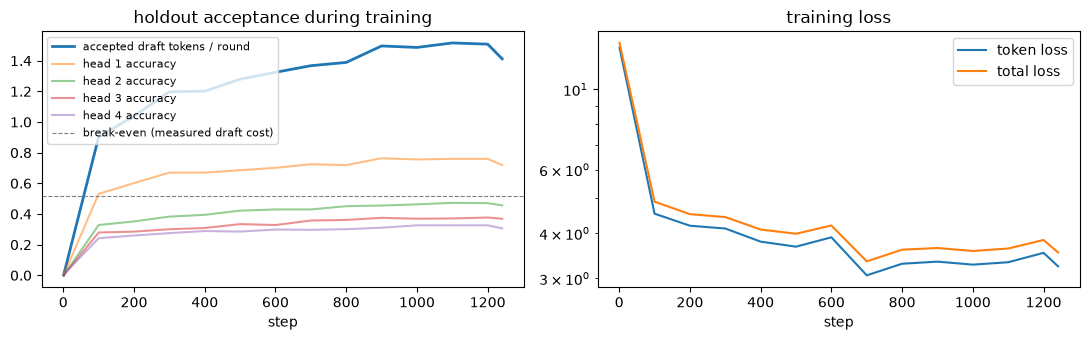

In [13]:
import matplotlib.pyplot as plt

steps = [s for s, _ in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(steps, [m["accepted_per_round"] for _, m in history], lw=2, label="accepted draft tokens / round")
for k in range(HORIZON):
    ax[0].plot(steps, [m[f"head{k+1}"] for _, m in history], alpha=0.5, label=f"head {k+1} accuracy")
ax[0].axhline(0.52, ls="--", c="gray", lw=0.8, label="break-even (measured draft cost)")
ax[0].set_xlabel("step"); ax[0].set_title("holdout acceptance during training"); ax[0].legend(fontsize=8)
ax[1].plot(steps, [m["token_loss"] for _, m in history], label="token loss"); ax[1].plot(steps, [m["loss"] for _, m in history], label="total loss")
ax[1].set_xlabel("step"); ax[1].set_yscale("log"); ax[1].legend(); ax[1].set_title("training loss")
plt.tight_layout(); plt.show()

## Teacher-forced acceptance on the holdout set

Upper-bound estimate of the speculative decoding gain. For every position of every holdout page
the draft proposes `HORIZON` tokens from the target's real hidden state (windows of the last
`CONTEXT_LENGTH` states, computed in batches), then the target's recorded tokens act as the
verifier. Each verification is assumed to cost one target decode step plus one draft call.

Statistics are per page, so the 95% confidence intervals below reflect page-to-page variation
(t-interval over pages; bootstrap for the ratio-based speedup).

In [14]:
from fastdocling.data import load_trace

EVAL_BATCH = 64           # windows per draft call  (TARGET_DECODE_TPS is set in the config cell)
draft.eval()


@torch.inference_mode()
def proposals_for_page(x: torch.Tensor) -> torch.Tensor:
    """[n, HORIZON] greedy proposals at every cursor, using the last CONTEXT_LENGTH states."""
    n = x.shape[0]
    out = torch.empty(n, HORIZON, dtype=torch.long, device=x.device)
    head = draft(x[:CONTEXT_LENGTH].unsqueeze(0))[0]              # cursors < CONTEXT_LENGTH: causal prefix
    out[: min(n, CONTEXT_LENGTH)] = F.linear(head, lm_head).argmax(-1)[: min(n, CONTEXT_LENGTH)]
    if n > CONTEXT_LENGTH:
        windows = x.unfold(0, CONTEXT_LENGTH, 1).permute(0, 2, 1)[1:]  # [n-ctx, ctx, D], ends at cursor
        for s in range(0, windows.shape[0], EVAL_BATCH):
            chunk = windows[s : s + EVAL_BATCH]
            out[CONTEXT_LENGTH + s : CONTEXT_LENGTH + s + chunk.shape[0]] = F.linear(draft(chunk)[:, -1], lm_head).argmax(-1)
    return out


def simulate(proposals: torch.Tensor, tokens: torch.Tensor) -> tuple[int, int, int]:
    """Greedy verification with the live loop's alignment: returns (tokens, verifications, accepted).

    At cursor c the state s_c is known and so is token c+1 (the target's bonus token from the
    previous step); the draft proposes tokens c+2 .. c+1+HORIZON.  A round yields 1 + accepted tokens.
    Token 1 comes from the prefill (no round), matching ``speculative_generate``.
    """
    n = tokens.shape[0] - 1                       # generated tokens: tokens[1:]
    prop, tok = proposals.tolist(), tokens.tolist()
    cursor = verifications = accepted_total = 0
    while cursor < n - 1:                         # at cursor n-1 token n is already known: nothing left to draft
        verifications += 1
        accepted = 0
        for k in range(min(HORIZON, n - cursor - 1)):
            if prop[cursor][k] != tok[cursor + 2 + k]:
                break
            accepted += 1
        accepted_total += accepted
        cursor += 1 + accepted
    return n, verifications, accepted_total


# single-stream draft latency per call (what a real speculative loop would pay per verification)
with torch.inference_mode():
    probe = torch.zeros(1, CONTEXT_LENGTH, input_dim(FEATURES), device=device)
    def sync():   # CUDA and MPS both queue work asynchronously; without this we time launches
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()

    for _ in range(5):
        draft(probe)
    sync()
    t0 = perf_counter()
    for _ in range(50):
        F.linear(draft(probe)[:, -1], lm_head).argmax(-1)
    sync()
    draft_call_seconds = (perf_counter() - t0) / 50

rows = []
for info in tqdm(holdout_infos, unit="page", desc="acceptance"):
    x, _, tokens = load_trace(info, FEATURES)
    x, tokens = x.to(device), tokens.to(device)
    n, verifications, accepted = simulate(proposals_for_page(x), tokens)
    baseline_s = n / TARGET_DECODE_TPS
    spec_s = verifications * (1 / TARGET_DECODE_TPS + draft_call_seconds)
    rows.append(dict(tokens=n, verifications=verifications, accepted=accepted,
                     acc_per_verif=accepted / verifications, tokens_per_step=n / verifications,
                     spec_tps=n / spec_s, speedup=baseline_s / spec_s))


def ci95(values: np.ndarray) -> tuple[float, float, float]:
    """mean and 95% t-interval half-width (pages are the sampling unit)."""
    from scipy import stats
    m = values.mean(); h = stats.t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
    return m, m - h, m + h


def bootstrap_ratio(num: np.ndarray, den: np.ndarray, iters: int = 10_000, seed: int = 0) -> tuple[float, float, float]:
    rng = np.random.default_rng(seed); idx = rng.integers(0, len(num), (iters, len(num)))
    r = num[idx].sum(1) / den[idx].sum(1)
    return num.sum() / den.sum(), *np.percentile(r, [2.5, 97.5])


tok = np.array([r["tokens"] for r in rows], float); ver = np.array([r["verifications"] for r in rows], float)
acc = np.array([r["accepted"] for r in rows], float)
m, lo, hi = ci95(np.array([r["acc_per_verif"] for r in rows]))
print(f"{len(rows)} holdout pages, {int(tok.sum()):,} tokens; draft call {draft_call_seconds*1000:.2f} ms")
print(f"accepted per verification:  {m:.3f}  [95% CI {lo:.3f}, {hi:.3f}]  (per-page mean)")
m, lo, hi = bootstrap_ratio(tok, ver)
print(f"tokens per target step:     {m:.3f}  [95% CI {lo:.3f}, {hi:.3f}]  (pooled, bootstrap)")
m, lo, hi = ci95(np.array([r["spec_tps"] for r in rows]))
print(f"est. speculative throughput: {m:,.1f} tok/s  [95% CI {lo:,.1f}, {hi:,.1f}]  vs baseline {TARGET_DECODE_TPS:.0f} tok/s")
m, lo, hi = bootstrap_ratio(tok / TARGET_DECODE_TPS, ver * (1 / TARGET_DECODE_TPS + draft_call_seconds))
print(f"est. speedup:               {m:.2f}x  [95% CI {lo:.2f}, {hi:.2f}]  (not an end-to-end benchmark)")

acceptance:   0%|          | 0/101 [00:00<?, ?page/s]

101 holdout pages, 116,137 tokens; draft call 0.50 ms
accepted per verification:  1.223  [95% CI 1.166, 1.281]  (per-page mean)
tokens per target step:     2.169  [95% CI 2.109, 2.229]  (pooled, bootstrap)
est. speculative throughput: 382.6 tok/s  [95% CI 372.7, 392.5]  vs baseline 188 tok/s
est. speedup:               1.98x  [95% CI 1.93, 2.04]  (not an end-to-end benchmark)


In [15]:
print(f"Num params: {sum(p.numel() for p in draft.parameters() if p.requires_grad):,}")

Num params: 4,027,968


## Measured speedup: real speculative decoding on holdout pages

The loop is *draft proposes `HORIZON` tokens -> target verifies them in one KV-cached step ->
accept the matching prefix + the target's own next token -> roll the cache back*. The baseline is
the same loop with no draft (plain greedy, one token per step), so both sides share prefill, cache
handling and Python overhead. Wall-clock decode throughput is **pooled over pages** -- total tokens
divided by total seconds, and total tokens divided by total target steps -- with a bootstrap interval
that resamples pages. Holdout pages run 600-7000 tokens, so an unweighted mean over pages answers
"what does a typical page do", not "is this faster overall", and the two can differ by 2x. The
per-page mean is printed beside each pooled figure: when the two diverge, one long page owns the
token total, and that is worth knowing before reading anything else.

`fastdocling.decode` provides three runtimes, selected by `DECODE_BACKEND` in the config cell:

| backend | runtime | install | speculative loop |
|---|---|---|---|
| `mlx` | mlx-vlm | `uv sync --extra mlx` (Apple Silicon) | yes -- draft, verify and accept fuse into one lazy graph, one sync per round |
| `transformers` | HF eager | plain `uv sync` (CUDA / MPS / CPU) | yes -- cache rolled back with `DynamicCache.crop` |
| `vllm` | vLLM | `uv sync --extra cuda` (CUDA) | **no** -- baseline only |

`auto` picks the best speculative-capable backend for the machine: `mlx` on Apple Silicon,
`transformers` elsewhere. vLLM is never chosen automatically, because it owns its KV cache inside
the scheduler and exposes no rollback, so the latent draft cannot be driven from it. What it
measures instead is the number everything else is quoted against: the target's honest single-stream
decode rate, and the two differ enormously. Measured on one RTX 5070 Ti, same model, same page:

| backend | decode | per step |
|---|---|---|
| `transformers` (HF eager) | 57 tok/s | 17.5 ms |
| `vllm` | ~1,150 tok/s | 0.87 ms |

HF eager decoding of a 258M model is launch-bound -- 30 layers of small kernels per token is fixed
overhead that the tiny draft does not pay -- so a speedup quoted over that baseline is flattering by
construction. **Read acceptance rate and tokens/step across backends; read wall-clock only within
one, and take the headline speedup from the runtime you would actually deploy.**

On MLX the draft runs in-process (`fastdocling.draft_mlx`, weights ported from the torch model); on
transformers the trained torch module is used directly. Either way its vocabulary head is restricted
to the ~19k tokens that occur in the training pages' DocTags output (FR-Spec style), which makes the
projection ~4x cheaper; tokens outside that set are never proposed but are still produced by the
target.

Verification is greedy, so in exact arithmetic the output is identical to plain decoding (checked in
float32 on both loops, including the partial-acceptance rollback). In bf16 a multi-token block and a
single-token step can resolve near-tied argmaxes differently, typically by +/-1 in `<loc_N>` digits;
"agreement" reports how close the outputs are.

In [ ]:
import difflib

from transformers.image_utils import load_image

from fastdocling.data import output_vocab
from fastdocling.decode import available, cached_generate, get_decoder

# 8 pages, not 3.  Every headline below is pooled (total tokens / total seconds), holdout
# pages run 600-7000 tokens, and with 3 of them a single long page can be 80% of the token
# total -- the "aggregate" is then a measurement of that one page.  8 costs 16 decodes here
# and is reused by the vLLM sweep below, where each config also pays an engine build.
SPEC_PAGES = 8          # holdout pages decoded end to end (each twice: baseline + speculative)
DRAFT_WINDOW = CONTEXT_LENGTH      # recent states the draft sees at inference
IMAGES = ROOT / "data/images"
DECODES = CACHE / "decodes"        # stored end-to-end decodes; see fastdocling.decode.cached_generate
FEATURE_KEYS = ("last_hidden_state",) if FEATURES == "last" else ("layer_2", "layer_14", "layer_27")

decoder = get_decoder(DECODE_BACKEND)   # loads the target once per kernel; reused by every cell below
print(f"decode backend: {decoder.name} ({decoder.model_id});  installed here: {', '.join(available())}")

# Recompute this here so the decode cells also work after loading ``draft`` manually.
DRAFT_KEY = hashlib.sha1(b"".join(v.detach().cpu().contiguous().numpy().tobytes() for v in draft.state_dict().values())).hexdigest()[:12]

# Build the pruned head from TRAINING pages only (the holdout must be able to contain OOV tokens),
# and key the cache on the page set so a changed corpus or split cannot reuse a stale file.
vocab = output_vocab(train_infos, cache=TRACES / f"output_vocab_{CORPUS_KEY}.npy")
vocab_set = set(vocab.tolist())
# ``supports_draft`` only says the backend can speculate at all; ``accepts_latent_draft`` says it
# can speculate with *ours*.  vLLM speculates with a drafter of its own (ngram), so attaching the
# trained draft there is impossible and a speedup measured there is not this draft's.
if decoder.accepts_latent_draft:
    decoder.attach_draft(draft, lm_head, context_length=CONTEXT_LENGTH, horizon=HORIZON,
                         window=DRAFT_WINDOW, vocab=vocab)
    print(f"draft attached; head restricted to {len(vocab):,} tokens, window {DRAFT_WINDOW}")
elif decoder.supports_draft:
    print(f"{decoder.name} speculates with its own drafter ({decoder.speculative_config['method']}), "
          f"not the latent draft -- see the vLLM sweep below.")
else:
    print(f"{decoder.name} cannot run the draft (no KV rollback): baseline throughput only.")

# Greedy decoding is deterministic: a page's baseline depends only on (backend, target), its
# speculative decode only on (backend, target, draft weights, horizon, window, vocabulary).  Both
# are stored on disk under exactly that key, so re-running these cells after a restart, or after
# changing only the page list, skips every decode already done.  The backend is part of the key
# because timings from different runtimes are not comparable and their bf16 argmaxes can differ.
# Stored timings come from the session that measured them; REFRESH_DECODES=True re-runs and re-times.
BASE_KEY = dict(kind="baseline", backend=decoder.name, model=decoder.model_id)
SPEC_KEY = dict(kind="spec", backend=decoder.name, model=decoder.model_id, draft=DRAFT_KEY,
                horizon=HORIZON, window=DRAFT_WINDOW, vocab=CORPUS_KEY, features=FEATURE_KEYS)
decode_hits = Counter()


def decode(path: Path, use_draft: bool):
    """End-to-end decode of the page image at ``path``: plain greedy (baseline) or speculative."""
    extra = dict(horizon=HORIZON, history_limit=DRAFT_WINDOW) if use_draft else {}
    res, hit = cached_generate(decoder, path, use_draft=use_draft, cache_dir=DECODES,
                               key=SPEC_KEY if use_draft else BASE_KEY, refresh=REFRESH_DECODES,
                               feature_keys=FEATURE_KEYS, **extra)
    decode_hits["cached" if hit else "fresh"] += 1
    return res


def image_for(info) -> Path:
    return IMAGES.joinpath(*info.path.stem.split("__")).with_suffix(".png")


# One short uncached decode first: the very first call on a fresh kernel pays lazy kernel
# compilation (~900 ms of prefill on CUDA vs ~130 ms warm), which would land entirely on page 1.
decoder.generate(load_image(str(image_for(holdout_infos[0]))), use_draft=False, max_tokens=8)

measured = []
for info in tqdm(holdout_infos[:SPEC_PAGES], unit="page", desc="decode"):
    base = decode(image_for(info), use_draft=False)
    # Totals (tokens / seconds / rounds), not just the per-page rates: pooling needs the
    # numerators and denominators separately, and a rate has already thrown them away.
    row = dict(tokens=len(base.tokens), base_seconds=base.decode_seconds, base_tps=base.decode_tps,
               ms_base=1000 * base.decode_seconds / len(base.tokens),
               oov=np.mean([t not in vocab_set for t in base.tokens]))
    if decoder.supports_draft:
        spec = decode(image_for(info), use_draft=True)
        row.update(spec_tokens=len(spec.tokens), spec_seconds=spec.decode_seconds, spec_rounds=spec.rounds,
                   spec_tps=spec.decode_tps, speedup=spec.decode_tps / base.decode_tps,
                   tokens_per_round=spec.tokens_per_round,
                   ms_round=1000 * spec.decode_seconds / spec.rounds,
                   agreement=difflib.SequenceMatcher(a=base.tokens, b=spec.tokens, autojunk=False).ratio())
    measured.append(row)

vals = lambda k: np.array([m[k] for m in measured], float)


def bootstrap_speedup(num_a: np.ndarray, den_a: np.ndarray, num_b: np.ndarray, den_b: np.ndarray,
                      iters: int = 10_000, seed: int = 0) -> tuple[float, float, float]:
    """Ratio of two pooled rates measured on the *same* pages, with a paired bootstrap CI.

    A speedup is a ratio of two ratios, so it cannot go through ``bootstrap_ratio``; the
    resampling unit is still one page, drawn from both arms at once so the pairing survives.
    """
    rng = np.random.default_rng(seed); idx = rng.integers(0, len(num_a), (iters, len(num_a)))
    r = (num_a[idx].sum(1) / den_a[idx].sum(1)) / (num_b[idx].sum(1) / den_b[idx].sum(1))
    return (num_a.sum() / den_a.sum()) / (num_b.sum() / den_b.sum()), *np.percentile(r, [2.5, 97.5])


# Headline figures are POOLED: total tokens / total seconds, total tokens / total rounds, with a
# bootstrap CI over pages.  "Is this faster overall" is a question about the whole workload; an
# unweighted mean over pages answers a different one, giving a 600-token page the same vote as a
# 7000-token page -- which on this corpus moves tokens/step by 2x.  The per-page mean is printed
# beside each figure anyway, because the gap between the two is the diagnostic: when it opens,
# one long page owns the token total and the pages disagree with each other.
print(f"{len(measured)} holdout pages decoded end to end on {decoder.name}, {int(vals('tokens').sum()):,} tokens "
      f"({decode_hits['cached']} decodes from cache, {decode_hits['fresh']} fresh)")
print("figures are pooled over pages (total tokens / total time), bootstrap 95% CI over pages;")
print("the unweighted per-page mean follows each one -- a large gap means one page dominates.")
m, lo, hi = bootstrap_ratio(vals("tokens"), vals("base_seconds"))
print(f"baseline decode:        {m:6.1f} tok/s  [95% CI {lo:.1f}, {hi:.1f}]   "
      f"({1000 * vals('base_seconds').sum() / vals('tokens').sum():.2f} ms/step;  per page {vals('base_tps').mean():.1f} tok/s)")
if decoder.supports_draft:
    m, lo, hi = bootstrap_ratio(vals("spec_tokens"), vals("spec_seconds"))
    print(f"speculative decode:     {m:6.1f} tok/s  [95% CI {lo:.1f}, {hi:.1f}]   "
          f"({1000 * vals('spec_seconds').sum() / vals('spec_rounds').sum():.2f} ms/round; per page {vals('spec_tps').mean():.1f} tok/s)")
    m, lo, hi = bootstrap_speedup(vals("spec_tokens"), vals("spec_seconds"), vals("tokens"), vals("base_seconds"))
    print(f"MEASURED SPEEDUP:       {m:6.2f}x     [95% CI {lo:.2f}, {hi:.2f}]   (per page {vals('speedup').mean():.2f}x)")
    m, lo, hi = bootstrap_ratio(vals("spec_tokens"), vals("spec_rounds"))
    print(f"tokens per target step: {m:6.2f}      [95% CI {lo:.2f}, {hi:.2f}]   (per page {vals('tokens_per_round').mean():.2f};"
          f" 1 + accepted draft tokens)")
    pooled_break_even = ((vals("spec_seconds").sum() / vals("spec_rounds").sum())
                         / (vals("base_seconds").sum() / vals("tokens").sum()))
    print(f"break-even tokens/round at this draft cost: {pooled_break_even:.2f}   "
          f"output agreement with greedy: {vals('agreement').mean():.4f}")
else:
    print(f"(no speculative loop on {decoder.name} -- this is the target baseline only)")
print(f"\nTARGET_DECODE_TPS for this machine on {decoder.name}: {vals('tokens').sum() / vals('base_seconds').sum():.1f} "
      f"(pooled; config cell currently says {TARGET_DECODE_TPS:.1f})")

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/470 [00:00<?, ?it/s]

decode backend: transformers (ibm-granite/granite-docling-258M);  installed here: transformers, vllm
draft attached; head restricted to 35,878 tokens, window 32


decode:   0%|          | 0/3 [00:00<?, ?page/s]

3 holdout pages decoded end to end on transformers, 3,119 tokens (3 decodes from cache, 3 fresh)
baseline decode:          55.4 tok/s  [95% CI 54.8, 55.9]   (18.06 ms/step)
speculative decode:       96.6 tok/s  [95% CI 82.5, 110.6]   (21.34 ms/round)
MEASURED SPEEDUP:         1.74x     [95% CI 1.49, 2.00]
tokens per target step:   2.06      [95% CI 1.78, 2.35]  (1 + accepted draft tokens)
break-even tokens/round at this draft cost: 1.18   output agreement with greedy: 0.9959

TARGET_DECODE_TPS for this machine on transformers: 55.4 (config cell currently says 188.0)


## The bar to beat: vLLM's own speculative decoding

The speedup above is measured against HF eager, which is launch-bound: profiling one decode step of
this 258M target shows **2.2 ms of GPU work behind 18 ms of CPU dispatch**, so most of what a
multi-token block saves there is Python, not compute. A production runtime has no such slack -- and
it ships speculative decoding of its own. The honest question is therefore not "does the latent
draft beat plain decoding?" but "does it beat what the runtime already gives away for free?"

vLLM's drafters that need no trained model are **`ngram`** (propose the continuation of the longest
recent n-gram match) and its GPU variant. DocTags is the regime they were built for -- repeated
`<loc_N>` runs, table rows, form boilerplate -- so this is a fair fight. (`suffix` needs
`arctic_inference`; `eagle`/`eagle3`/`medusa`/`draft_model` need a draft checkpoint in vLLM's own
format, which the latent draft is not: it reads a window of target *hidden states* and emits
`HORIZON` parallel heads, matching none of those contracts.)

**Read the two regimes separately.** *Latency* is one page at a time -- what speculative decoding
exists to improve, and the regime the latent draft's measured speedup lives in. *Throughput* batches
every page into one scheduler pass, which is what the card can actually deliver. A drafter can win
one and lose the other, and on this target it does.

**Read tokens/step and tok/s separately too.** tokens/step is the drafter's quality; tok/s is what
the page cost. They routinely disagree here: ngram's matcher runs on the CPU, in the critical path
of every round, so a configuration can accept plenty and still finish slower. The `baseline
async=off` row is the control for one part of that -- configuring any ngram drafter makes vLLM
disable async scheduling, a cost the drafter does not choose and the plain baseline does not pay.
Comparing ngram against that row, rather than against `baseline`, isolates what the drafting itself
costs.

One engine is one speculative configuration, so the sweep builds and tears down an engine per
setting (~50 s cold, ~12 s once vLLM's compile cache is warm). Only `num_speculative_tokens` is
swept: raising `prompt_lookup_min` was measured strictly worse at every k, and it is also the only
knob that would not need its own engine. Results go through the same decode cache as everything
else, keyed by configuration, so a repeated sweep rebuilds only what it must.

In [9]:
# 8, matching SPEC_PAGES above.  The figures below are pooled over pages, so the page count is
# what stops one 7000-token page from being the whole measurement; 3 was not enough (one page
# held 84% of the tokens).  8 is also as far as this can go cheaply: every configuration needs
# its own engine (~12 s warm, ~50 s cold) and the batched row for each is re-measured whenever
# the page list changes, so the cost is 6 engines x (8 pages + 1 batched run).
VLLM_SWEEP_PAGES = 8      # holdout pages per configuration (the same pages the cell above decoded)
VLLM_GPU_FRACTION = 0.35  # vLLM pre-allocates this share of the card up front; raise it if the GPU is yours alone

if "vllm" not in available():
    print("vLLM is not installed here (`uv sync --extra cuda`); skipping the runtime-drafter sweep.")
else:
    from fastdocling.decode.vllm_decoder import (ASYNC_CONTROL, DRAFTER_CONTROL, NGRAM_SWEEP,
                                                 sweep_speculative)

    sweep_pages = [image_for(info) for info in holdout_infos[:VLLM_SWEEP_PAGES]]
    # Two controls, because configuring ngram silently changes two other things: it disables
    # async scheduling AND drops vLLM to the V1 model runner.  Measuring a no-drafter engine
    # under each condition in turn is what separates "the drafter cost this" from "turning the
    # drafter on cost this".
    sweep_configs = [None, ASYNC_CONTROL, DRAFTER_CONTROL, *NGRAM_SWEEP]
    bar = tqdm(total=len(sweep_configs) * (len(sweep_pages) + 1), unit="run", desc="vllm sweep")
    vllm_rows = sweep_speculative(sweep_pages, sweep_configs, cache_dir=DECODES,
                                  gpu_memory_utilization=VLLM_GPU_FRACTION,
                                  refresh=REFRESH_DECODES, batched=True, progress=bar)
    bar.close()

    latency, batched = ([r for r in vllm_rows if r["mode"] == m] for m in ("latency", "throughput"))
    group = lambda rows: {r["config"]: [x for x in rows if x["config"] == r["config"]] for r in rows}
    fresh = sum(not r["cached"] for r in vllm_rows)
    print(f"{len(sweep_pages)} holdout pages x {len(sweep_configs)} configs on vLLM "
          f"({len(vllm_rows) - fresh} runs from cache, {fresh} fresh)\n")

    # Aggregation.  Every headline column is POOLED over pages -- total tokens / total seconds,
    # total tokens / total rounds -- because "is this configuration faster" is a question about
    # the whole workload, not about an average page.  An unweighted mean over pages answers the
    # other question and, with pages spanning 600-7000 tokens, the two disagree by up to 2x: a
    # short page that accepts well can outvote a long page holding most of the tokens.  Rows
    # carry rates rather than totals, so the denominators are reconstructed exactly (seconds =
    # tokens / tok_s, rounds = tokens / tokens_per_round).  The per-page mean stays in the last
    # two columns -- when it sits far above the pooled figure, one long page owns the total.
    page_mean = lambda rows, k: float(np.mean([r[k] for r in rows]))          # unweighted, diagnostic
    n_tok = lambda rows: np.array([r["tokens"] for r in rows], float)
    n_sec = lambda rows: np.array([r["tokens"] / r["decode_tps"] for r in rows], float)
    n_rnd = lambda rows: np.array([r["tokens"] / r["tokens_per_round"] for r in rows], float)
    tps = lambda rows: float(n_tok(rows).sum() / n_sec(rows).sum())           # pooled tok/s
    per_step = lambda rows: float(n_tok(rows).sum() / n_rnd(rows).sum())      # pooled tokens/step

    # -- one page at a time: the regime speculative decoding is for, and the one the latent
    #    draft's measured speedup lives in.  Every config decodes the same pages in the same
    #    order, which is what lets the speedup CIs below resample pages pairwise.
    by_config = group(latency)
    base_rows = by_config["baseline"]
    base_tps = tps(base_rows)
    print("LATENCY  (batch 1, one page at a time)   pooled over pages; the last two columns are")
    print("         the unweighted per-page mean of the same two metrics, kept for contrast")
    print(f"  {'configuration':24s}{'tok/s':>9s}{'vs base':>9s}{'tokens/step':>13s}{'acc/proposed':>15s}{'GPU':>7s}"
          f"{'per-page tok/s':>16s}{'per-page t/step':>17s}")
    for label, rows in by_config.items():
        proposed = sum(r["draft_tokens"] for r in rows)
        accepted = sum(sum(r["accepted_per_pos"]) for r in rows)
        print(f"  {label:24s}{tps(rows):9.1f}{tps(rows) / base_tps:8.2f}x"
              f"{per_step(rows):13.3f}{(accepted / proposed if proposed else 0):15.3f}"
              f"{page_mean(rows, 'gpu_util'):6.0f}%"
              f"{page_mean(rows, 'decode_tps'):16.1f}{page_mean(rows, 'tokens_per_round'):17.3f}")

    # -- all pages in flight at once: what the card can actually do.  Speculative decoding spends
    #    spare GPU capacity, and batching has already spent it, so it should lose here.  These
    #    rows are one measurement of every page at once, so they are pooled by construction.
    if batched:
        by_batch = group(batched)
        base_batch = by_batch["baseline"][0]["tps"]
        print("\nTHROUGHPUT  (all pages batched into one scheduler pass)")
        print(f"  {'configuration':24s}{'tok/s':>9s}{'vs base':>9s}{'tokens/step':>13s}{'GPU':>7s}")
        for label, rows in by_batch.items():
            r = rows[0]
            print(f"  {label:24s}{r['tps']:9.1f}{r['tps'] / base_batch:8.2f}x"
                  f"{r['tokens_per_round']:13.3f}{r['gpu_util']:6.0f}%")

    best = max(by_config.items(), key=lambda kv: tps(kv[1]))
    best_quality = max(by_config.items(), key=lambda kv: per_step(kv[1]))
    m, lo, hi = bootstrap_speedup(n_tok(best[1]), n_sec(best[1]), n_tok(base_rows), n_sec(base_rows))
    print(f"\nfastest single-stream config: {best[0]}  ({tps(best[1]):.1f} tok/s pooled, "
          f"{m:.2f}x the no-drafter baseline [95% CI {lo:.2f}, {hi:.2f}])")
    m, lo, hi = bootstrap_ratio(n_tok(best_quality[1]), n_rnd(best_quality[1]))
    print(f"best tokens/step:             {best_quality[0]}  ({m:.3f} pooled [95% CI {lo:.3f}, {hi:.3f}], "
          f"per-page mean {page_mean(best_quality[1], 'tokens_per_round'):.3f})")
    # Where the wall-clock actually goes, step by step down the controls (pooled throughput).
    drafters = {k: v for k, v in by_config.items() if not k.startswith("baseline")}
    if drafters:
        fastest = max(drafters.items(), key=lambda kv: tps(kv[1]))
        steps, prev = [], base_tps
        for label in ("baseline async=off", "baseline async=off runner=v1"):
            if label in by_config:
                step_tps = tps(by_config[label])
                steps.append((label.replace("baseline ", ""), prev, step_tps))
                prev = step_tps
        steps.append((fastest[0], prev, tps(fastest[1])))
        print("\nwhere the wall-clock goes (each row is one thing ngram changes):")
        for what, before, after in steps:
            print(f"  {what:28s} {before:6.0f} -> {after:6.0f} tok/s   {1 - after / before:+6.1%}")
        print("ngram matching runs on the CPU inside every round, which is why the GPU column "
              "falls\nrather than rises when a drafter is switched on.")
    if measured and decoder.accepts_latent_draft:
        print(f"\nfor comparison, the latent draft on {decoder.name}: "
              f"{vals('spec_tokens').sum() / vals('spec_rounds').sum():.3f} tokens/step at "
              f"{vals('spec_tokens').sum() / vals('spec_seconds').sum():.1f} tok/s (both pooled).\n"
              f"Compare tokens/step across runtimes; wall-clock only within one.")

vllm sweep:   0%|          | 0/20 [00:00<?, ?run/s]

INFO 09-14 16:50:44 [api_utils.py:286] non-default args: {'max_model_len': 8192, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.35, 'disable_log_stats': True, 'limit_mm_per_prompt': {'image': 1}, 'model': 'ibm-granite/granite-docling-258M'}
INFO 09-14 16:50:44 [model.py:684] Resolved architecture: Idefics3ForConditionalGeneration
INFO 09-14 16:50:44 [model.py:2021] Using max model len 8192
WARNING 09-14 16:50:44 [model.py:981] Model does not support mm_device_do_normalize, forcing mm_device_do_normalize = False.
INFO 09-14 16:50:45 [scheduler.py:277] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09-14 16:50:45 [kernel.py:369] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(EngineCore pid=149417) INFO 09-14 16:50:57 [core.py:123] Initializing a V1 LLM engine (v0.29.0) with config: model='ibm-granite/granite-docling-258M', speculative_config=None, tokenizer='ibm-granite/granite-

(EngineCore pid=149417) [transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


(EngineCore pid=149417) INFO 09-14 16:50:58 [parallel_state.py:1775] world_size=1 rank=0 local_rank=0 distributed_init_method=file:///tmp/vllm_dist_7f1ce1e722f743959781cb11d00515cb backend=nccl
(EngineCore pid=149417) INFO 09-14 16:50:58 [parallel_state.py:2119] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, PCP rank 0, TP rank 0, EP rank N/A, EPLB rank N/A
(EngineCore pid=149417) INFO 09-14 16:50:58 [gpu_worker.py:429] Using V2 Model Runner
(EngineCore pid=149417) INFO 09-14 16:50:59 [model_runner.py:382] Loading model from scratch...
(EngineCore pid=149417) INFO 09-14 16:50:59 [cuda.py:551] Using backend AttentionBackendEnum.FLASH_ATTN for vit attention
(EngineCore pid=149417) INFO 09-14 16:50:59 [mm_encoder_attention.py:372] Using AttentionBackendEnum.FLASH_ATTN for MMEncoderAttention.
(EngineCore pid=149417) INFO 09-14 16:50:59 [kernel.py:369] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])


(EngineCore pid=149417) Failed to get device capability: SM 12.x requires CUDA >= 12.9.
(EngineCore pid=149417) Failed to get device capability: SM 12.x requires CUDA >= 12.9.


...

(EngineCore pid=150702) INFO 09-14 16:54:28 [gpu_model_runner.py:5471] Model loading took 0.49 GiB memory and 1.113925 seconds
(EngineCore pid=150702) INFO 09-14 16:54:28 [utils.py:306] Using LBNHC KV cache layout.
(EngineCore pid=150702) INFO 09-14 16:54:29 [gpu_model_runner.py:6546] Encoder cache will be initialized with a budget of 8192 tokens, and profiled with 7 image items of the maximum feature size.
(EngineCore pid=150702) INFO 09-14 16:54:30 [caching.py:343] reconstructed serializable fn from standalone compile artifacts. num_artifacts=4 num_submods=31
(EngineCore pid=150702) INFO 09-14 16:54:30 [decorators.py:313] Directly load AOT compilation from path /root/.cache/vllm/torch_compile_cache/torch_aot_compile/9fd0ce46ef1a2ef9171a8f0109ef9f0d7370afe844d30510d63297fd62463d3e/rank_0_0/model
(EngineCore pid=150702) INFO 09-14 16:54:30 [monitor.py:53] torch.compile took 0.18 s in total
(EngineCore pid=150702) INFO 09-14 16:54:30 [monitor.py:81] Initial profiling/warmup run took 0.0

JIT kernel warmup (1 compile keys): 100%|██████████| 1/1 [00:00<00:00, 406.11kernel/s, ComputeSlotMappingKernel (1 keys)]
(EngineCore pid=150702) 2026-09-14 16:54:32,727 - INFO - autotuner.py:2789 - flashinfer.jit: [Autotuner]: Loaded 0 configs from /root/.cache/vllm/flashinfer_autotune_cache/flashinfer/0.6.18/a9da5675b1be18bfc4c3b5ecf4f4ae0f39a528e02d3bc48839cec5cb003f1cce/autotune_configs.json
(EngineCore pid=150702) 2026-09-14 16:54:32,727 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=150702) 2026-09-14 16:54:32,735 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=150702) 2026-09-14 16:54:32,738 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /root/.cache/vllm/flashinfer_autotune_cache/flashinfer/0.6.18/a9da5675b1be18bfc4c3b5ecf4f4ae0f39a528e02d3bc48839cec5cb003f1cce/autotune_configs.json (0 new, 0 from previous config)


(EngineCore pid=150702) INFO 09-14 16:54:32 [kernel_warmup.py:266] Running FlashInfer autotune with 8192 tokens.
(EngineCore pid=150702) INFO 09-14 16:54:32 [gpu_model_runner.py:6955] Rank 0: Torch profiler disabled for CUDA graph capture


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 44/44 [00:00<00:00, 50.36it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 44/44 [00:00<00:00, 53.60it/s]


(EngineCore pid=150702) INFO 09-14 16:54:35 [gpu_model_runner.py:7001] Graph capturing finished in 2 secs, took 0.26 GiB
(EngineCore pid=150702) INFO 09-14 16:54:35 [gpu_worker.py:797] CUDA graph pool memory: 0.26 GiB (actual), 0.31 GiB (estimated), difference: 0.05 GiB (19.4%).
(EngineCore pid=150702) INFO 09-14 16:54:35 [gpu_worker.py:860] Free memory on device (12.75/15.47 GiB) on startup. Desired GPU memory utilization is (0.35, 5.41 GiB). Actual usage is 1.33 GiB for consumed memory (weights + non-torch), 2.84 GiB for peak activation, and 0.26 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=888534733` (0.83 GiB) to fit into requested memory, or `--kv-cache-memory=8766417408` (8.16 GiB) to fully utilize gpu memory. Current kv cache memory in use is 1.24 GiB.
(EngineCore pid=150702) INFO 09-14 16:54:35 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(EngineCore pid=150702) INFO 

## Taking the draft into vLLM: the Medusa route

The windowed draft cannot be handed to vLLM. Not because of KV rollback — vLLM rejects and rolls
back internally for every drafter it hosts — but because of the *proposer interface*: `custom_class`
receives token ids and never hidden states, `eagle`/`eagle3` want an autoregressive drafter in their
own model format, and `medusa`, which does take hidden states and does parallel per-head argmax, is
handed `[num_reqs, hidden_size]` — the **current position only**. There is nowhere to put the window.

`DRAFT_ARCH = "medusa"` trains the model that fits: `HORIZON` independent residual SiLU heads over
the target's final hidden state, architecturally identical to vLLM's `ResidualBlock`, sharing the
target's frozen `lm_head` (`original_lm_head=True`). It emits the same `[B, T, HORIZON, 576]` as the
windowed draft, so everything above — loss, acceptance, decode — is unchanged.

**Know the bar before reading the result.** Configuring `medusa` makes vLLM disable async scheduling
*and* fall back to the V1 model runner (it is in neither `EagleModelTypes` nor the V2 allowlist) —
the `baseline async=off runner=v1` control above: pooled over the pages measured here, **482 tok/s
against 702**, a 2.07 ms target step instead of 1.42 ms. Beating plain vLLM therefore needs roughly
**3.5 tokens/step** once the head's own cost is counted — the cell below re-derives that bar from
whatever the run actually measures — while dropping the window is exactly what lowers acceptance.
The windowed draft reaches about **2.0 tokens/step pooled** over holdout pages *with* the window.

(All four figures are pooled, not per-page means. The gap is not cosmetic: on the three pages
measured so far the Medusa head's per-page mean reads 2.07 tokens/step and its pooled value 1.20,
because one 7050-token page carries 84% of the tokens and accepts far less than the short ones.)

Two further costs are specific to this route, both measured rather than assumed:

- **No FR-Spec vocabulary pruning.** vLLM 0.29 cannot load a Medusa checkpoint carrying a
  `token_map` at all (`load_weights` registers the parameter but omits it from the set it returns,
  so the loader rejects it), and pruning without one trips an assert. The draft head here spans the
  full 100,352 tokens rather than the ~19k DocTags uses.
- **No window means no positional context**, so head 1 is predicting the next-next token from a
  single vector — the regime where the windowed draft earns most of its margin.

`eagle3` keeps async scheduling and the V2 runner, so its break-even is ~1.1 rather than ~3.5. If
the number below lands short, that is the route to evaluate next, not a bigger Medusa head.

In [ ]:
if DRAFT_ARCH != "medusa":
    print(f'DRAFT_ARCH is {DRAFT_ARCH!r}; set it to "medusa" and retrain to export a vLLM drafter.')
elif "vllm" not in available():
    print("vLLM is not installed here (`uv sync --extra cuda`); skipping the in-engine measurement.")
else:
    from fastdocling.decode.vllm_decoder import ASYNC_CONTROL, DRAFTER_CONTROL, sweep_speculative

    # The head is written in vLLM's own Medusa layout: blocks.{h}.layers.{l}.weight plus one
    # shared lm_heads.0.weight.  No vocab= -- token_map cannot be loaded by vLLM 0.29.
    MEDUSA_DIR = export_medusa_checkpoint(draft, lm_head, CACHE / f"medusa_vllm_{DRAFT_KEY}")
    print(f"exported {MEDUSA_DIR}  ({json.loads((MEDUSA_DIR / 'config.json').read_text())})")

    medusa_cfg = {"method": "medusa", "model": str(MEDUSA_DIR), "num_speculative_tokens": HORIZON}
    med_pages = [image_for(info) for info in holdout_infos[:VLLM_SWEEP_PAGES]]
    bar = tqdm(total=4 * (len(med_pages) + 1), unit="run", desc="medusa")
    med_rows = sweep_speculative(med_pages, [None, ASYNC_CONTROL, DRAFTER_CONTROL, medusa_cfg],
                                 cache_dir=DECODES, gpu_memory_utilization=VLLM_GPU_FRACTION,
                                 refresh=REFRESH_DECODES, batched=True, progress=bar)
    bar.close()

    lat = {r["config"]: [] for r in med_rows if r["mode"] == "latency"}
    for r in med_rows:
        if r["mode"] == "latency":
            lat[r["config"]].append(r)
    # Pooled over pages, exactly as in the sweep above, and it matters most here: this cell's
    # whole argument is an arithmetic comparison of per-round wall-clock, which is a property of
    # the total work, not of an average page.  Measured on a 3-page set, one 729-token page
    # reached 3.142 tokens/step while the 7050-token page next to it -- 84% of all the tokens --
    # reached 1.089; the unweighted page mean read 2.072 and the pooled figure 1.197.  The
    # per-page mean stays in the last two columns, where a gap flags exactly that situation.
    page_mean = lambda rows, k: float(np.mean([x[k] for x in rows]))         # unweighted, diagnostic
    n_tok = lambda rows: np.array([r["tokens"] for r in rows], float)
    n_sec = lambda rows: np.array([r["tokens"] / r["decode_tps"] for r in rows], float)
    n_rnd = lambda rows: np.array([r["tokens"] / r["tokens_per_round"] for r in rows], float)
    tps = lambda rows: float(n_tok(rows).sum() / n_sec(rows).sum())          # pooled tok/s
    per_step = lambda rows: float(n_tok(rows).sum() / n_rnd(rows).sum())     # pooled tokens/step
    base = tps(lat["baseline"])

    print(f"\n{'configuration':30s}{'tok/s':>9s}{'vs plain vLLM':>15s}{'tokens/step':>13s}{'GPU':>7s}"
          f"{'per-page tok/s':>16s}{'per-page t/step':>17s}")
    for label, rows in lat.items():
        print(f"{label:30s}{tps(rows):9.1f}{tps(rows) / base:14.2f}x"
              f"{per_step(rows):13.3f}{page_mean(rows, 'gpu_util'):6.0f}%"
              f"{page_mean(rows, 'decode_tps'):16.1f}{page_mean(rows, 'tokens_per_round'):17.3f}")
    print("(first four columns pooled over pages: total tokens / total seconds, / total rounds)")

    # A drafted round pays the async=off/V1 step *plus* the head, and is judged against plain
    # vLLM.  The head's cost is not assumed: back it out of the measurement, since a round takes
    # tokens_per_step / tok_s.
    med = [k for k in lat if k.startswith("medusa")][0]
    control = tps(lat.get("baseline async=off runner=v1", lat["baseline"]))
    got, med_tps = per_step(lat[med]), tps(lat[med])
    step_ctl, round_ms = 1000 / control, got / med_tps * 1000
    head_ms = round_ms - step_ctl
    need = base * (step_ctl + head_ms) / 1000

    print(f"\nplain vLLM step {1000 / base:.3f} ms | drafted round {round_ms:.3f} ms "
          f"= {step_ctl:.3f} (async=off, V1) + {head_ms:.3f} (the head itself)")
    print(f"break-even {need:.3f} tokens/step   ({base / control:.3f} would be the bar if the head were free)")
    m, lo, hi = bootstrap_ratio(n_tok(lat[med]), n_rnd(lat[med]))
    s, s_lo, s_hi = bootstrap_speedup(n_tok(lat[med]), n_sec(lat[med]),
                                      n_tok(lat["baseline"]), n_sec(lat["baseline"]))
    print(f"achieved   {m:.3f} tokens/step [95% CI {lo:.3f}, {hi:.3f}]  "
          f"(per-page mean {page_mean(lat[med], 'tokens_per_round'):.3f})")
    print(f"           -> {s:.2f}x plain vLLM [95% CI {s_lo:.2f}, {s_hi:.2f}]   "
          f"[{'CLEARS' if got > need else 'SHORT OF'} break-even]")

    # Where the head's time goes: the shared lm_head runs over the full vocabulary, once per head,
    # because token_map cannot be loaded.  That projection scales linearly in vocabulary size.
    full = int(lm_head.shape[0])
    pruned_ms = head_ms * len(vocab) / full
    pruned_tps = got / ((step_ctl + pruned_ms) / 1000)
    print(f"\nthe head's {head_ms:.3f} ms is dominated by {HORIZON} x [{full:,} x {HIDDEN_SIZE}] logits.")
    print(f"were the {len(vocab):,}-token pruning loadable, that falls to ~{pruned_ms:.3f} ms "
          f"-> ~{pruned_tps:.0f} tok/s = {pruned_tps / base:.2f}x plain vLLM.")
    # Which half is short is a question the numbers answer, not a fixed conclusion: pooling the
    # pages moved tokens/step from 2.07 to 1.20 on the first 3-page run, which is enough to move
    # acceptance from "above the free-head bar" to "below it".  So decide it here.
    if got <= need:
        free_bar = base / control
        if pruned_tps > base:
            print("\nSo acceptance is not what falls short here -- the blocked vocabulary pruning is.")
        elif got < free_bar:
            print(f"\nBoth halves fall short: acceptance is {got:.3f} tokens/step against {free_bar:.3f}, "
                  f"the bar a *free*\nhead would still have to clear, and the unpruned head adds "
                  f"{head_ms:.3f} ms per round on top.")
        else:
            print(f"\nAcceptance clears the free-head bar ({got:.3f} vs {free_bar:.3f}), but pruning alone "
                  f"would not close\nthe gap either (~{pruned_tps / base:.2f}x plain vLLM).")
        print("eagle3 keeps async scheduling and the V2 runner (break-even ~1.1) and takes a pruned\n"
              "head; that is the route to evaluate before enlarging this one.")

## Out-of-domain evaluation

The draft is trained on ML papers. Docling's real workloads are broader: tax forms and their
instructions, court opinions and legislation, standards (RFCs, NIST), central-bank minutes, lecture
notes, UN resolutions, and non-ML science. `scripts/fetch_ood.py` downloads one or two public PDFs
per category and `fastdocling-prep render data/ood/docs data/ood/images` renders them. The cell
below runs the live speculative loop on the first `OOD_PAGES_PER_DOC` pages of each document and
reports per category:

- **tokens/step** and **speedup**: same live measurement as above.
- **OOV**: share of the target's output tokens that are outside the draft's pruned vocabulary,
  i.e. tokens the draft can never propose. High OOV on a category means the vocabulary was built
  from too narrow a corpus, independent of the draft's quality.
- **agreement**: bf16 block-vs-single-step agreement with plain greedy decoding, as before.

In [10]:
OOD_IMAGES = ROOT / "data/ood/images"
OOD_PAGES_PER_DOC = 3

ood_pages = []                                   # (category, doc, page path)
for cat_dir in sorted(p for p in OOD_IMAGES.iterdir() if p.is_dir()):
    for doc_dir in sorted(p for p in cat_dir.iterdir() if p.is_dir()):
        for page in sorted(doc_dir.glob("*.png"))[:OOD_PAGES_PER_DOC]:
            ood_pages.append((cat_dir.name, doc_dir.name, page))
if not ood_pages:
    raise FileNotFoundError("run `uv run python scripts/fetch_ood.py` then `uv run fastdocling-prep render data/ood/docs data/ood/images`")

ood = []
for cat, doc, page in tqdm(ood_pages, unit="page", desc="ood"):
    base = decode(page, use_draft=False)
    row = dict(category=cat, doc=doc, page=page.stem, tokens=len(base.tokens), base_tps=base.decode_tps,
               oov=np.mean([t not in vocab_set for t in base.tokens]),
               truncated=base.tokens[-1] not in {100328, 100257, 100352})
    if decoder.supports_draft:
        spec = decode(page, use_draft=True)
        row.update(speedup=spec.decode_tps / base.decode_tps, tokens_per_round=spec.tokens_per_round,
                   agreement=difflib.SequenceMatcher(a=base.tokens, b=spec.tokens, autojunk=False).ratio())
    ood.append(row)


def summarize(rows, label):
    v = lambda k: np.array([r[k] for r in rows], float)
    ci = lambda a: f"{a.mean():.2f} \u00b1{(1.96 * a.std(ddof=1) / np.sqrt(len(a))) if len(a) > 1 else 0:.2f}"
    head = f"{label:14s} {len(rows):3d} pages  {int(v('tokens').sum()):6,} tok"
    if not decoder.supports_draft:                       # baseline-only backend
        return f"{head}   baseline {v('base_tps').mean():6.1f} tok/s   OOV {v('oov').mean():5.1%}"
    return (f"{head}   tokens/step {ci(v('tokens_per_round'))}   speedup {ci(v('speedup'))}x   "
            f"OOV {v('oov').mean():5.1%}   agreement {v('agreement').mean():.3f}")


print(f"backend {decoder.name}")
if measured:
    print(summarize(measured, "in-domain (ML)"))
for cat in sorted({r["category"] for r in ood}):
    print(summarize([r for r in ood if r["category"] == cat], cat))
print(summarize(ood, "ALL OOD"))
print(f"({decode_hits['cached']} decodes read from {DECODES}, {decode_hits['fresh']} run fresh this session)")
trunc = [r for r in ood if r["truncated"]]
if trunc:
    print(f"note: {len(trunc)} page(s) hit max_tokens without </doctag>: " + ", ".join(f"{r['doc']}/{r['page']}" for r in trunc))

ood:   0%|          | 0/29 [00:00<?, ?page/s]

KeyboardInterrupt: 

## Which tokens does the draft get right?

One holdout page decoded with the live speculative loop. Each round the draft proposes `horizon`
tokens, the target verifies them in a single forward pass, and the round ends with one token the
*target* chose — the **bonus** token. It is free: the verification pass already produced logits for
the position after the last accepted draft token, so every round emits `accepted + 1` tokens even
when the draft is rejected outright. That is the floor that keeps speculative decoding from ever
being slower than plain decoding.

<span style="background:rgba(35,164,85,.32);box-shadow:inset 0 -2px 0 rgba(35,164,85,.95);border-radius:3px;padding:0 4px">accepted</span>
the draft proposed it and the target agreed &nbsp;
<span style="background:rgba(214,131,16,.30);box-shadow:inset 2px 0 0 rgba(214,131,16,1);border-radius:3px;padding:0 4px">bonus</span>
the target's own token, one per round &nbsp;
<span style="background:rgba(125,133,144,.24);border-radius:3px;padding:0 4px">prefill</span>
came out of the prompt pass, before any round

Green is the win, amber is the work the target still had to do; the amber left-edges also mark the
round boundaries, so a long green run between them is a round where the draft carried the page. The
table groups acceptance by token type, which shows where a parallel-heads draft succeeds
(predictable structure) and fails (content).

In [11]:
import html, re
from collections import Counter
from IPython.display import HTML, display

SHOW_PAGE = 1           # index into holdout_infos
MAX_CHARS = 15000         # how much of the page to render

if not decoder.supports_draft:
    raise RuntimeError(f"{decoder.name} runs no draft, so there is no per-token provenance to show; "
                       "set DECODE_BACKEND to 'mlx' or 'transformers'")

info = holdout_infos[SHOW_PAGE]
spec = decode(image_for(info), use_draft=True)   # read from the decode cache if this page was decoded above
tok = decoder.tokenizer

# reconstruct per-token provenance from the round history: each round = accepted*k + 1 bonus
kind = ["prefill"]
for a in spec.accepted_hist:
    kind += ["accepted"] * a + ["bonus"]
kind = kind[: len(spec.tokens)]

def token_type(text: str) -> str:
    if re.fullmatch(r"<loc_\d+>", text): return "<loc_N>"
    if re.fullmatch(r"</?[a-z_0-9]+>", text): return "structure tag"
    if text.strip().isdigit(): return "number"
    if text.strip() == "": return "whitespace"
    if re.fullmatch(r"[^\w\s]+", text.strip()): return "punctuation"
    return "word piece"

# Translucent fills stay legible on light and dark themes; the shape cue (underline vs left bar)
# carries the same distinction as the hue, which green/amber alone would not for red-green vision.
STYLE = {
    "accepted": "background:rgba(35,164,85,.32);box-shadow:inset 0 -2px 0 rgba(35,164,85,.95)",   # draft was right
    "bonus":    "background:rgba(214,131,16,.30);box-shadow:inset 2px 0 0 rgba(214,131,16,1)",    # target's own token, closes a round
    "prefill":  "background:rgba(125,133,144,.24)",                                               # from the prompt pass, generated by nobody
}
pieces, by_type = [], {}
for t, k in zip(spec.tokens, kind):
    text = tok.decode([t])
    ty = token_type(text)
    by_type.setdefault(ty, Counter())[k] += 1
    pieces.append(f'<span title="{k}" style="{STYLE[k]};border-radius:2px">{html.escape(text)}</span>')
rendered = "".join(pieces)
if len(rendered) > MAX_CHARS * 6:
    rendered = rendered[: MAX_CHARS * 6] + " …"
display(HTML(f'<div style="font-family:monospace;font-size:12px;white-space:pre-wrap;line-height:1.5;'
             f'border:1px solid rgba(128,128,128,0.5);padding:8px;max-height:480px;overflow:auto;color:inherit;background:transparent">{rendered}</div>'))

total_acc = sum(c["accepted"] for c in by_type.values()); total_bonus = sum(c["bonus"] for c in by_type.values())
print(f"{info.path.stem[-60:]}\n{len(spec.tokens)} tokens in {spec.rounds} rounds: "
      f"{total_acc} accepted by draft ({total_acc/len(spec.tokens):.0%}), {total_bonus} from target, "
      f"{spec.tokens_per_round:.2f} tokens/round\n")
print(f"{'token type':16s}{'count':>7s}{'accepted':>10s}{'share of accepted':>19s}")
for ty, c in sorted(by_type.items(), key=lambda kv: -sum(kv[1].values())):
    n = sum(c.values()); a = c["accepted"]
    print(f"{ty:16s}{n:7d}{a/n:10.0%}{a/max(1,total_acc):19.0%}")

erable Visual Models From Natural Language Supervision__0001
1250 tokens in 648 rounds: 601 accepted by draft (48%), 648 from target, 1.93 tokens/round

token type        count  accepted  share of accepted
word piece          864       42%                61%
punctuation         204       73%                25%
number              112       46%                 9%
whitespace           46       52%                 4%
structure tag        24       46%                 2%
